# Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-pastel')

import seaborn as sns


%matplotlib inline
# used to display your plots within the notebook.

# Load and Explore the Dataset

In [1]:
# Importing the dataset
df = pd.read_csv(r"C:\Users\yasha\OneDrive\Desktop\inlighntech.com\My projects\Python\New Year Sales Data.csv", encoding='latin-1')

In [2]:
# Checking the dataset
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [3]:
# Checking the rows and columns
df.shape

(11251, 15)

In [4]:
# Checking info about column names, non-null values and Data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


# Data Cleaning

In [5]:
# Checking null values
df.isnull().sum()

User_ID                 0
Cust_name               0
Product_ID              0
Gender                  0
Age Group               0
Age                     0
Marital_Status          0
State                   0
Zone                    0
Occupation              0
Product_Category        0
Orders                  0
Amount                 12
Status              11251
unnamed1            11251
dtype: int64

In [6]:
# Dropping the null values and unnecessary columns
df.drop(["Status", "unnamed1"], axis= 1, inplace=True, errors='ignore')

# Dropping rows with null values in other important columns.
important_cols = ['Gender', 'Age Group', 'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category', 'Orders', 'Amount']

df = df.dropna(subset=important_cols)

In [7]:
df.isnull().sum()

User_ID             0
Cust_name           0
Product_ID          0
Gender              0
Age Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Occupation          0
Product_Category    0
Orders              0
Amount              0
dtype: int64

In [8]:
#Converting the Amount column to an integer type
df['Amount'] = df['Amount'].astype(int)

# Data Overview and Summary

In [9]:
# Statistical Summary
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount
count,1.123900e+04,11239.000000,11239.000000,11239.000000,11239.000000
mean,1.003004e+06,35.410357,0.420055,2.489634,9453.610553
std,1.716039e+03,12.753866,0.493589,1.114967,5222.355168
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000
50%,1.003064e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004426e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


In [10]:
# Checking for unique values
df.nunique()

User_ID             3752
Cust_name           1250
Product_ID          2350
Gender                 2
Age Group              7
Age                   81
Marital_Status         2
State                 16
Zone                   5
Occupation            15
Product_Category      18
Orders                 4
Amount              6583
dtype: int64

In [11]:
for col in ['Gender', 'Age Group', 'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category']:
    if col in df.columns:
        print(f"\nUnique values in {col}:")
        print(df[col].unique())


Unique values in Gender:
['F' 'M']

Unique values in Age Group:
['26-35' '0-17' '18-25' '51-55' '46-50' '55+' '36-45']

Unique values in Marital_Status:
[0 1]

Unique values in State:
['Maharashtra' 'Andhra\xa0Pradesh' 'Uttar Pradesh' 'Karnataka' 'Gujarat'
 'Himachal Pradesh' 'Delhi' 'Jharkhand' 'Kerala' 'Haryana'
 'Madhya Pradesh' 'Bihar' 'Rajasthan' 'Uttarakhand' 'Telangana' 'Punjab']

Unique values in Zone:
['Western' 'Southern' 'Central' 'Northern' 'Eastern']

Unique values in Occupation:
['Healthcare' 'Govt' 'Automobile' 'Construction' 'Food Processing'
 'Lawyer' 'Media' 'Banking' 'Retail' 'IT Sector' 'Aviation' 'Hospitality'
 'Agriculture' 'Textile' 'Chemical']

Unique values in Product_Category:
['Auto' 'Hand & Power Tools' 'Stationery' 'Tupperware' 'Footwear & Shoes'
 'Furniture' 'Food' 'Games & Toys' 'Sports Products' 'Books'
 'Electronics & Gadgets' 'Decor' 'Clothing & Apparel' 'Beauty'
 'Household items' 'Pet Care' 'Veterinary' 'Office']


In [12]:
df = df.apply(lambda col: col.str.replace('\xa0', ' ', regex=False) if col.dtype == 'object' else col)

In [13]:
print(df['State'].unique())

['Maharashtra' 'Andhra Pradesh' 'Uttar Pradesh' 'Karnataka' 'Gujarat'
 'Himachal Pradesh' 'Delhi' 'Jharkhand' 'Kerala' 'Haryana'
 'Madhya Pradesh' 'Bihar' 'Rajasthan' 'Uttarakhand' 'Telangana' 'Punjab']


# Exploratory Data Analysis (EDA)

## Gender Analysis

Which gender has a higher purchasing power?

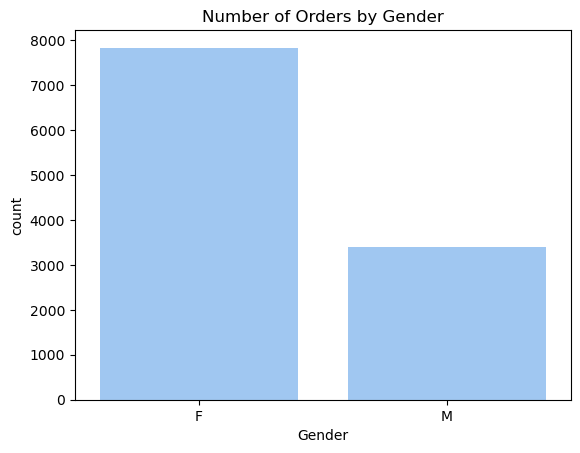

In [14]:
# Count Plot
sns.countplot(data=df, x='Gender')
plt.title("Number of Orders by Gender")
plt.show()

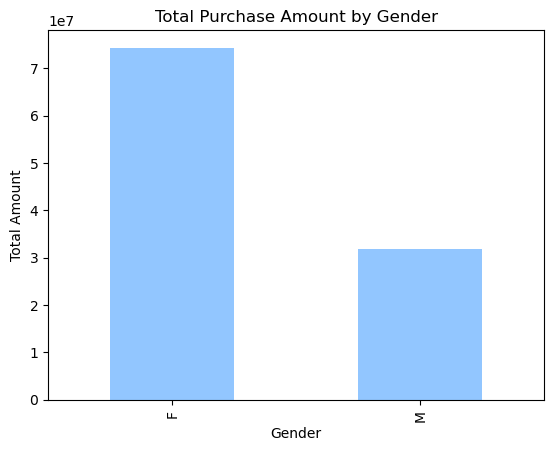

In [15]:
gender_amount = df.groupby('Gender')['Amount'].sum()
gender_amount.plot(kind='bar')
plt.title("Total Purchase Amount by Gender")
plt.ylabel("Total Amount")
plt.show()

### Findings Summary
* Female (F) customers generated approximately ₹7.4 crore (~74M) in total purchases
* Male (M) customers generated approximately ₹3.1 crore (~31M) in total purchases
* Females outspend males by roughly x2.4, making gender a strong differentiator in revenue contribution ~70% of total sales revenue
* Marketing and inventory decisions should prioritize female customer preferences
* Males, while likely present in reasonable order volume, have a notably lower spend per segment — worth investigating whether this is due to fewer orders or lower average order value

## Age Group Analysis

Which age group has the most purchases, and is there a trend in purchasing
power by age?

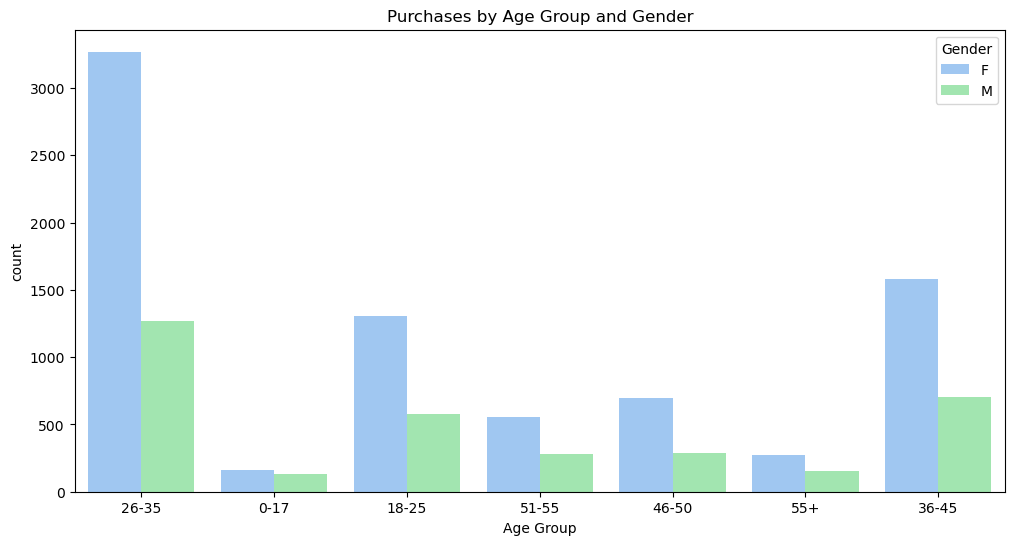

In [16]:
# count plot of age groups with hue as gender
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='Age Group', hue="Gender")
plt.title("Purchases by Age Group and Gender")
plt.show()

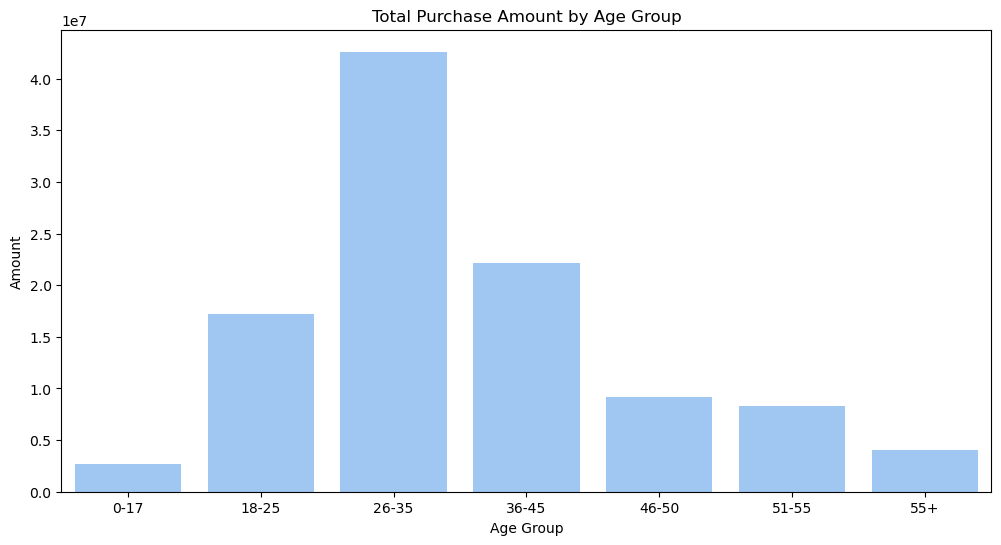

In [17]:
# bar chart showing total purchase amount by age group
age_amount = df.groupby('Age Group')['Amount'].sum().reset_index()
plt.figure(figsize=(12,6))
sns.barplot(data=age_amount, x='Age Group', y='Amount')
plt.title("Total Purchase Amount by Age Group")
plt.show()

### Findings Summary
* The 26–35 age group dominates, contributing nearly 40% of total purchase revenue — almost double the next closest group
* Spending drops sharply after 35, showing a clear inverted-V pattern peaking in the late 20s to mid-30s
* The 18–25 group shows decent spend, indicating younger adults are an emerging segment
* Customers 45 and older collectively contribute less than the 26–35 group alone

## State Analysis

Which states generate the highest number of orders and revenue?

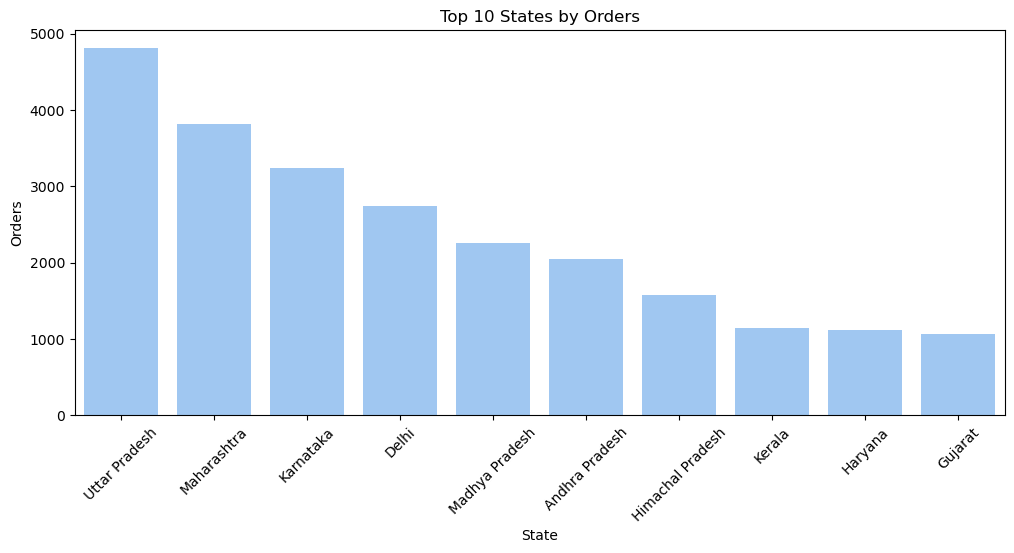

In [36]:
# bar charts for the number of orders and total amount by state
top_states_orders = df.groupby('State')['Orders'].sum().nlargest(10).reset_index()
plt.figure(figsize=(12,5))
sns.barplot(data=top_states_orders, x='State', y='Orders')
plt.xticks(rotation=45)
plt.title("Top 10 States by Orders")
plt.show()

#### Key Observations

* Uttar Pradesh leads by a wide margin, generating ~26% more orders than Maharashtra
* The top 3 states (UP, Maharashtra, Karnataka) together account for the bulk of all orders
* There's a steep drop-off after Delhi — the bottom 4 states each have fewer than 1,200 orders
* The high-order states are a mix of large population centers (UP, Maharashtra, Delhi) and tech/metro hubs (Karnataka)

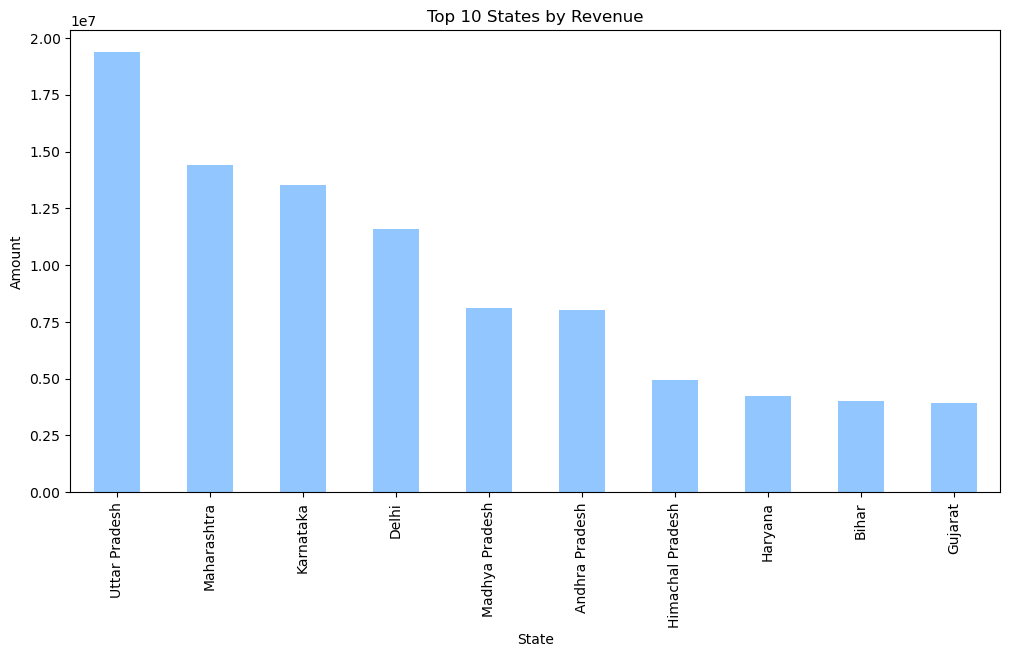

In [19]:
plt.figure(figsize=(12,6))
top_state_amount = df.groupby('State')['Amount'].sum().nlargest(10)
top_state_amount.plot(kind='bar')
plt.title("Top 10 States by Revenue")
plt.ylabel('Amount')
plt.show()

### Findings Summary
* Uttar Pradesh dominates revenue too, consistent with its #1 ranking in orders — high volume is clearly translating to high revenue
* The top 4 states (UP, Maharashtra, Karnataka, Delhi) are identical across both orders and revenue charts, confirming these are the core markets
* Bihar replaces Kerala from the orders chart, suggesting Bihar customers spend more per order despite placing fewer orders overall
* Revenue drops sharply after Delhi — the bottom 6 states each generate less than ₹0.85 crore

## Marital Status Analysis

How does marital status affect purchasing behavior?

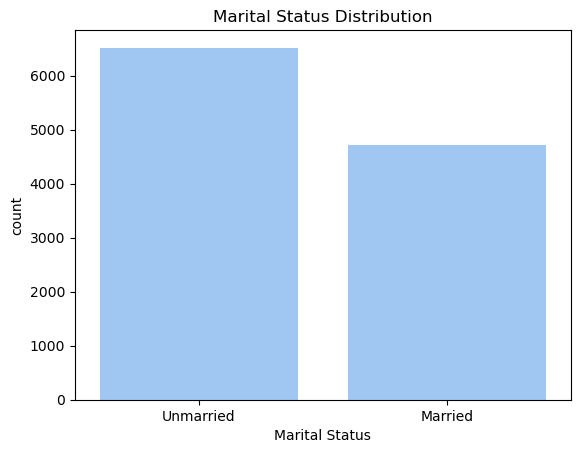

In [20]:
# count plot for marital status
ax = sns.countplot(data=df, x='Marital_Status')
plt.title('Marital Status Distribution')
ax.set_xticks([0,1])
ax.set_xticklabels(['Unmarried', 'Married'])
ax.set_xlabel('Marital Status')

plt.show()

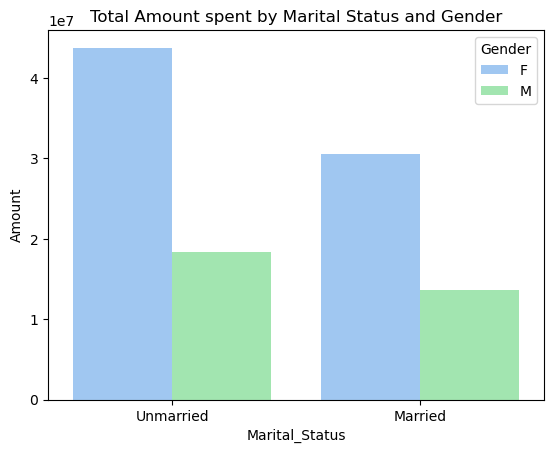

In [21]:
# bar chart of total amount spent by marital status, with gender as a hue

marital_amount = df.groupby(['Marital_Status', 'Gender'])['Amount'].sum().reset_index()

ax = sns.barplot(data=marital_amount, x='Marital_Status', y='Amount', hue='Gender')
plt.title("Total Amount spent by Marital Status and Gender")
ax.set_xticks([0,1])
ax.set_xticklabels(['Unmarried', 'Married'])
plt.show()

### Finding Summary
How Marital Status Affects Purchasing Behavior?

* Unmarried customers outspend married customers across both genders — unmarried females spend ~43% more than married females, and unmarried males spend ~37% more than married males
* Females dominate spending in both marital categories — unmarried females alone account for the largest single segment
* The pattern suggests unmarried individuals have higher discretionary spending, likely due to fewer shared financial obligations
* Across all four segments, the gender gap is consistent — females always outspend males regardless of marital status

## Occupation Analysis

Which occupations contribute most to sales?

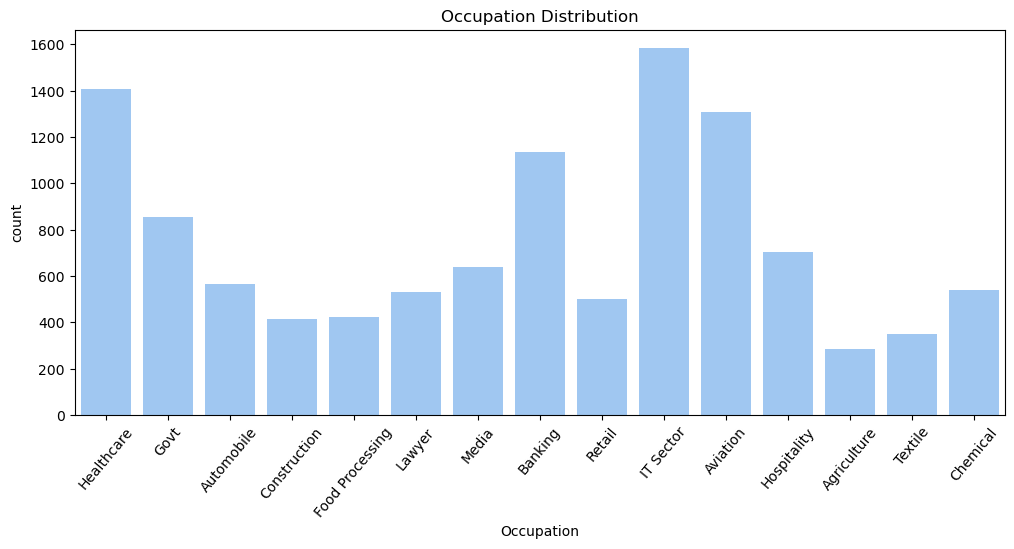

In [22]:
# count plot of occupation
plt.figure(figsize=(12,5))
sns.countplot(data=df, x='Occupation')
plt.title("Occupation Distribution")
plt.xticks(rotation=50)
plt.show()

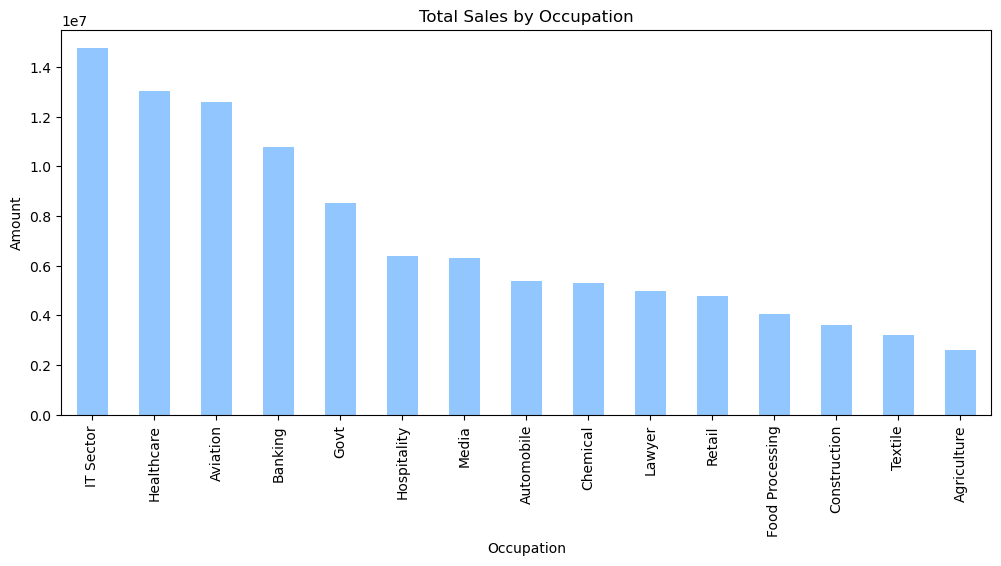

In [23]:
# barplot of total sales by occupation
plt.figure(figsize=(12,5))
occupation_amount = df.groupby('Occupation')['Amount'].sum().sort_values(ascending=False)
occupation_amount.plot(kind='bar')
plt.title("Total Sales by Occupation")
plt.ylabel('Amount')
plt.show()

### Findings Summary

* IT Sector leads all occupations, consistent with high salaries and strong online shopping habits
* The top 4 (IT, Healthcare, Aviation, Banking) are all high-income professional sectors, collectively contributing the majority of sales revenue
* There's a sharp cliff after Banking — Govt and below contribute significantly less
* Agriculture contributes the least, reflecting lower disposable income and limited digital commerce penetration

## Product Category Analysis

What product categories are the most popular, and which ones generate the
most revenue?

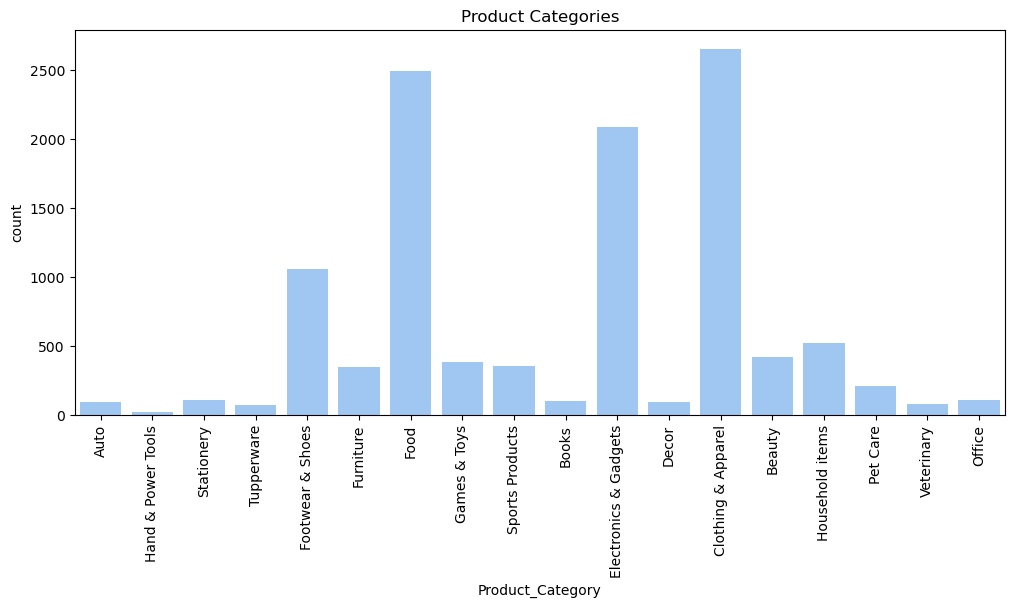

In [24]:
# count plot of product categories
plt.figure(figsize=(12,5))
sns.countplot(data=df, x='Product_Category')
plt.title('Product Categories')
plt.xticks(rotation=90)
plt.show()

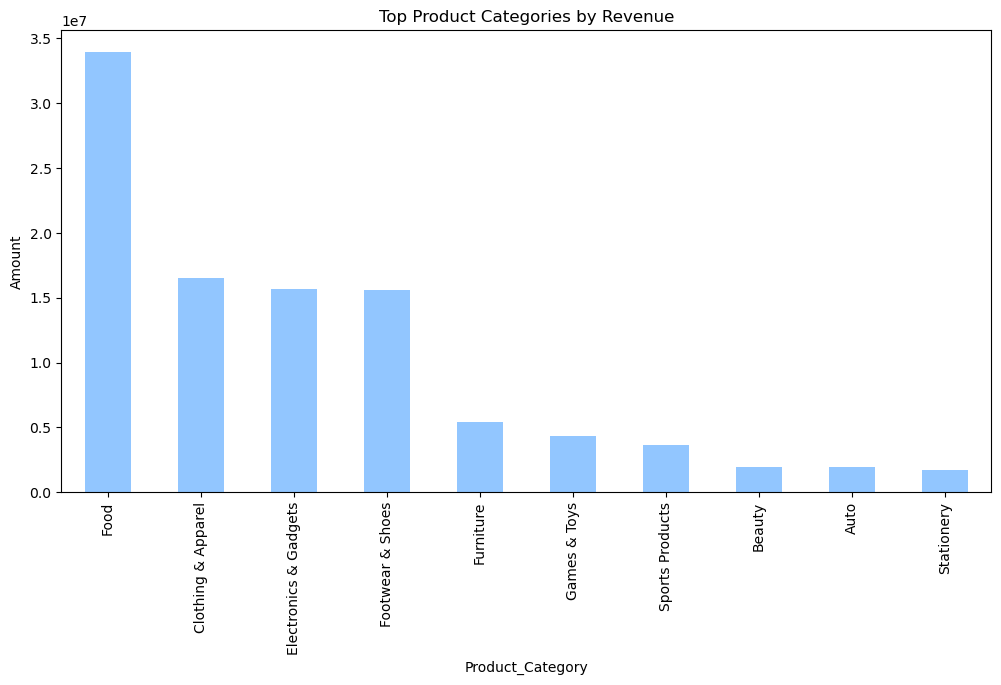

In [25]:
# bar chart of total amount by product category for the top categories
category_amount = df.groupby('Product_Category')['Amount'].sum().nlargest(10)
plt.figure(figsize=(12,6))
category_amount.plot(kind='bar')
plt.title("Top Product Categories by Revenue")
plt.ylabel('Amount')
plt.show()

### Findings Summary

* Food dominates by a massive margin — generating ~2× the revenue of the next closest category, making it the single most critical product segment
* Clothing, Electronics, and Footwear form a strong second tier, each contributing ~₹1.55 crore and nearly neck-and-neck with each other
* There's a dramatic cliff after Footwear — Furniture onwards contributes less than ₹0.55 crore each
* Beauty, Auto, and Stationery are the weakest categories, each under ₹0.20 crore
* The top 4 categories together account for roughly 80% of total revenue

## Conclusion

### Complete High-Purchasing Customer Profile

| Attribute | Profile |
|:--------:|:--------:|
| Gender | Female |
| Marital Status | Unmarried |
| Age Group | 26–35 |
| Occupation | IT |
| Sector | Healthcare, or Aviation |
| Location | Uttar Pradesh, Maharashtra, Karnataka, or Delhi |
| Top Categories | Food, Clothing & Apparel, Electronics & Gadgets, Footwear |
| Life Stage | Independent, salaried young professional |
| Spending Driver | High disposable income; everyday essentials + lifestyle upgrades |

#### Final Business Insight:
* Stock and promote Food, Clothing, Electronics, and Footwear heavily during New Year sales
* These four categories alone drive ~80% of revenue
* For the core segment — unmarried females aged 26–35 in IT/Healthcare — bundled offers across Clothing + Footwear + Electronics would likely yield the highest conversion and basket size

## Further Exploration

### Which age group contributes the most to each product category, and does this vary by gender?

In [26]:
age_cat_amount = df.groupby(['Product_Category', 'Age Group', 'Gender'])['Amount'].sum().reset_index()
age_cat_amount.head(10)

,Product_Category,Age Group,Gender,Amount
0,Auto,0-17,F,9732
1,Auto,0-17,M,47151
2,Auto,18-25,F,288925
3,Auto,18-25,M,61369
4,Auto,26-35,F,541529
5,Auto,26-35,M,353578
6,Auto,36-45,F,263399
7,Auto,36-45,M,61121
8,Auto,46-50,F,61132
9,Auto,46-50,M,18608


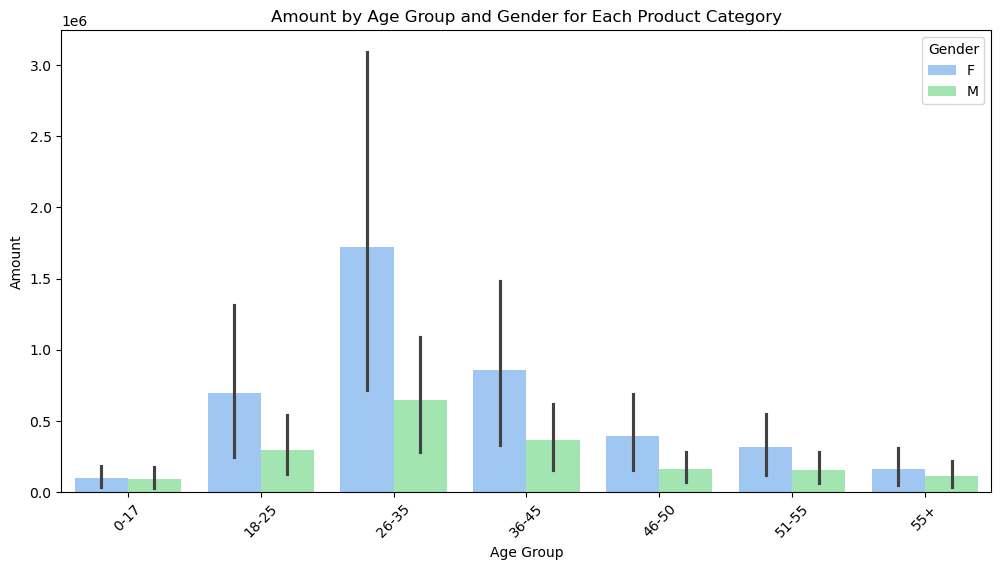

In [27]:
plt.figure(figsize=(12,6))
sns.barplot(data=age_cat_amount, x='Age Group', y='Amount', hue='Gender')
plt.title("Amount by Age Group and Gender for Each Product Category")
plt.xticks(rotation=45)
plt.show()

#### Key Observations

* 26–35 is the dominant age group for both genders, but female spend in this bracket (~ ₹1.72M) is nearly x3 that of males (~ ₹0.64M)
* Female dominance is consistent across every age group without exception — there is no age group where males outspend females
* The gender gap narrows in older age groups (51–55, 55+), suggesting more balanced spending behaviour post-50
* 18–25 females are a notable secondary segment, spending more than males aged 26–35

### How does the amount spent vary by marital status across different age groups?

In [28]:
marital_age_amount = df.groupby(['Marital_Status', 'Age Group'])['Amount'].sum().reset_index()
marital_age_amount.head()

,Marital_Status,Age Group,Amount
0,0,0-17,1655299
1,0,18-25,9781617
2,0,26-35,25008749
3,0,36-45,12870401
4,0,46-50,5472555


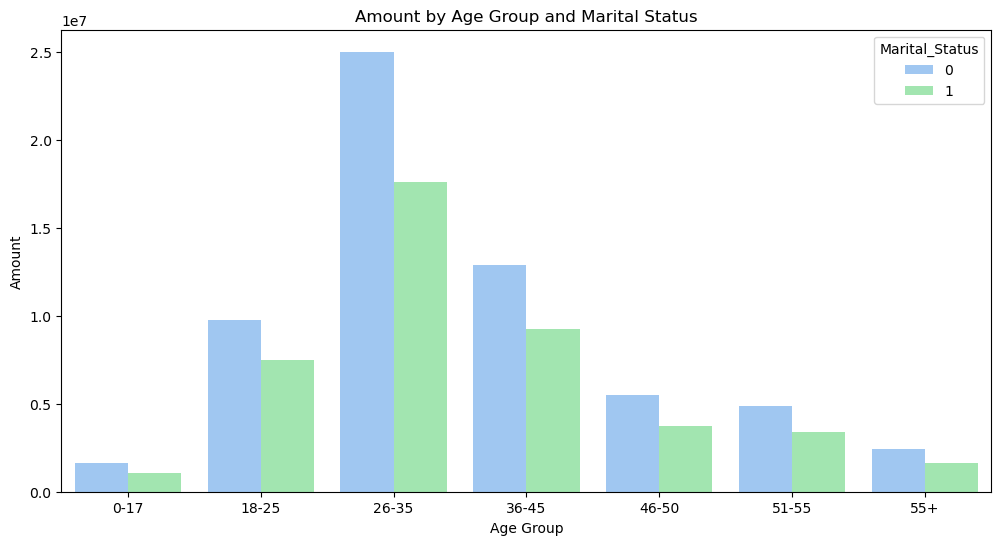

In [29]:
plt.figure(figsize=(12,6))
sns.barplot(data=marital_age_amount, x='Age Group', y='Amount', hue='Marital_Status')
plt.title("Amount by Age Group and Marital Status")
plt.show()

#### Key Observations
* Unmarried customers outspend married customers in every single age group — the pattern is universal and consistent
* The 26–35 unmarried segment is the absolute peak, spending ~₹2.50 crore — nearly 43% more than their married counterparts in the same age group
* Both marital groups follow the same inverted-V spending curve, peaking at 26–35 and declining steadily after 45
* The gap between unmarried and married narrows significantly in older age groups (46+), suggesting marital status becomes less influential as customers age
* 18–25 unmarried is a notable emerging segment — their spend (~₹0.98 crore) rivals married 36–45 customers

### Which states show the highest growth in orders and revenue, and are there seasonal spikes in sales?

In [30]:
# Create a synthetic 'Order_Date' column
# This assumes orders are spread daily over a period starting from '2025-01-01'
df['Order_Date'] = pd.to_datetime(pd.date_range(start='2025-01-01', periods=len(df), freq='D').to_series().reset_index(drop=True))

# Create Month-Year column
df['Month_Year'] = df['Order_Date'].dt.to_period('M').astype(str)

df['Month_Year'] = pd.Categorical(pd.cut(np.arange(len(df)), bins=12, labels=[f'2025-{str(m).zfill(2)}' for m in range(1,13)]))

# Group by State and Month_Year to get orders and revenue
state_month = df.groupby(['State', 'Month_Year'], observed=True).agg(Orders=('Orders', 'sum'),Revenue=('Amount', 'sum')).reset_index()

state_month.head()

,State,Month_Year,Orders,Revenue
0,Andhra Pradesh,2025-01,228,1784375
1,Andhra Pradesh,2025-02,149,968343
2,Andhra Pradesh,2025-03,117,728590
3,Andhra Pradesh,2025-04,132,639167
4,Andhra Pradesh,2025-05,244,1006059


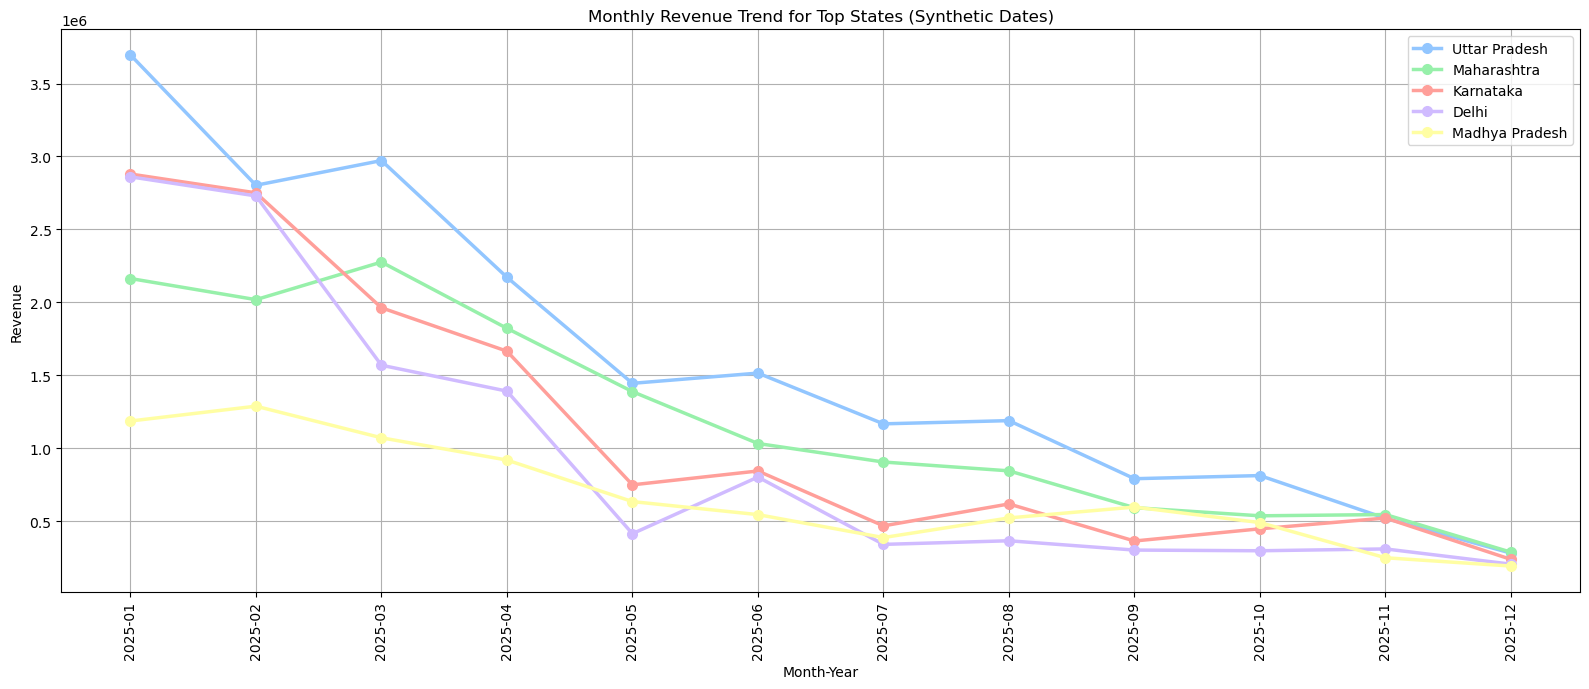

In [31]:
top_state_amount = df.groupby('State')['Amount'].sum().nlargest(5).reset_index()
top_state_amount.columns = ['State', 'Revenue']

top_states = top_state_amount['State'].head(5).tolist()# from earlier

plt.figure(figsize=(16, 7))
for i, st in enumerate(top_states):
    temp = state_month[state_month['State'] == st].sort_values('Month_Year')
    plt.plot(temp['Month_Year'], temp['Revenue'], 
             marker='o', 
             label=st,
             linewidth=2.5,
             markersize=7)

plt.xticks(rotation=90)
plt.title("Monthly Revenue Trend for Top States (Synthetic Dates)")
plt.xlabel("Month-Year")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

This dataset does not contain transaction dates.
Monthly revenue trends shown use synthetic dates for 
illustrative purposes only and do not reflect real 
seasonality. All other analyses (demographics, geography,
product categories) are based on actual data.

### Are there specific occupations that prefer particular product categories more than others?

In [32]:
occ_cat = df.groupby(['Occupation', 'Product_Category'])['Amount'].sum().reset_index()

pivot_occ_cat = occ_cat.pivot(index='Occupation', columns='Product_Category', values='Amount').fillna(0)
pivot_occ_cat

Product_Category,Auto,Beauty,Books,Clothing & Apparel,Decor,Electronics & Gadgets,Food,Footwear & Shoes,Furniture,Games & Toys,Hand & Power Tools,Household items,Office,Pet Care,Sports Products,Stationery,Tupperware,Veterinary
Occupation,,,,,,,,,,,,,,,,,,
Agriculture,18609.0,43951.0,28650.0,437296.0,14057.0,352614.0,930908.0,336636.0,80594.0,59005.0,23160.0,44079.0,4175.0,14926.0,91762.0,64976.0,42085.0,5604.0
Automobile,165586.0,94231.0,10364.0,870150.0,27818.0,1006127.0,1446125.0,717888.0,339543.0,149516.0,0.0,72656.0,931.0,26798.0,192694.0,73226.0,162058.0,12885.0
Aviation,244129.0,184171.0,222422.0,1716254.0,59625.0,1774366.0,4306343.0,1972899.0,618951.0,429440.0,19324.0,226272.0,7537.0,61840.0,360274.0,221390.0,166601.0,10460.0
Banking,253553.0,153034.0,109905.0,1738400.0,128764.0,1919127.0,2894943.0,1611992.0,605507.0,536829.0,123721.0,125833.0,6415.0,34061.0,307393.0,170462.0,37405.0,13266.0
Chemical,0.0,53654.0,73531.0,727491.0,29494.0,775674.0,1821161.0,864974.0,400051.0,195728.0,0.0,76917.0,5514.0,23289.0,102553.0,72463.0,70683.0,4259.0
Construction,80219.0,72604.0,29007.0,678794.0,36853.0,612017.0,860256.0,461129.0,299389.0,147294.0,15151.0,74165.0,3341.0,13567.0,97884.0,68010.0,37659.0,10172.0
Food Processing,146326.0,45802.0,28568.0,603436.0,41789.0,796316.0,1047875.0,729173.0,208654.0,189455.0,0.0,51764.0,773.0,21384.0,99376.0,37712.0,16311.0,5956.0
Govt,245267.0,183985.0,85864.0,1158860.0,19943.0,972346.0,3242839.0,1068102.0,481088.0,337338.0,38536.0,117981.0,5499.0,36174.0,276709.0,152984.0,87400.0,6297.0
Healthcare,103510.0,289418.0,97037.0,2249961.0,101273.0,1802020.0,4465342.0,1820931.0,563319.0,513805.0,14627.0,141446.0,11859.0,61895.0,603478.0,107586.0,78600.0,8479.0


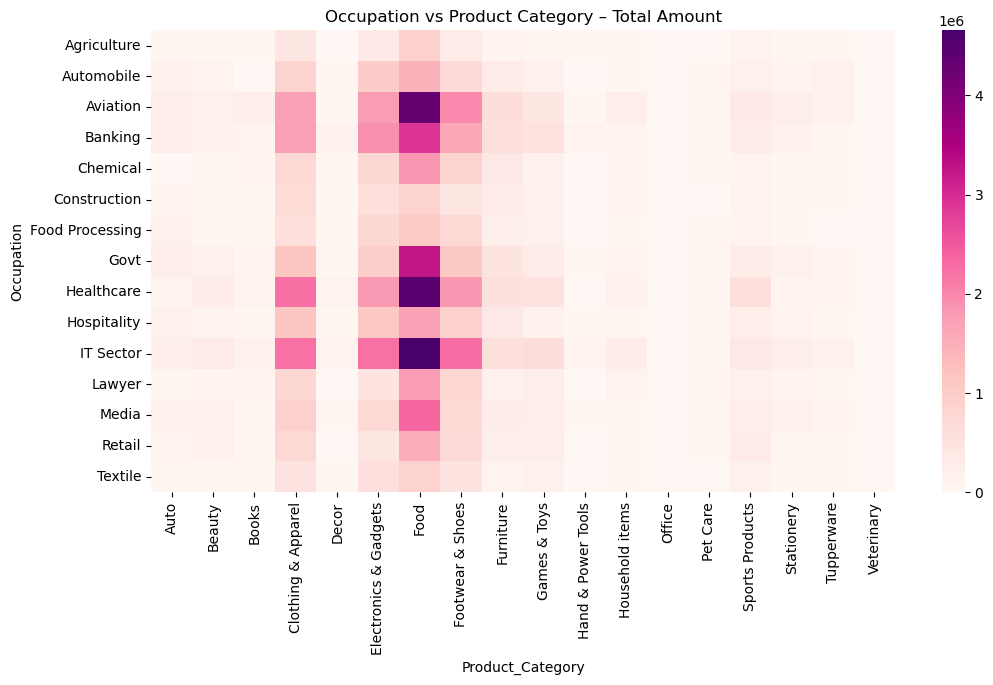

In [33]:
plt.figure(figsize=(12,6))
sns.heatmap(pivot_occ_cat, annot=False, cmap= 'RdPu')
plt.title("Occupation vs Product Category – Total Amount")
plt.show()

#### Key Observations

**Food dominates across all occupations**
* The entire Food column is noticeably darker than any other — it's the universal top category regardless of profession
* IT, Healthcare, and Aviation show the darkest Food cells, consistent with their higher overall spend

**Electronics & Gadgets is occupation-specific**
* Strongest in IT Sector, Healthcare, and Aviation — high-income, tech-comfortable professions
* Nearly invisible for Agriculture, Textile, Construction — lower digital affinity segments

**Clothing & Apparel shows broad but moderate appeal**
* Visible across most occupations with light-to-medium shading
* No single occupation dominates this category

**The right half of the heatmap is almost entirely blank**
* Categories like Books, Decor, Office, Pet Care, Tupperware, Veterinary generate near-zero spend across all occupations
* These are either niche or not relevant to New Year shopping behavior

**Agriculture, Textile, Construction are uniformly light**
* Consistent with their low overall revenue contribution
* No strong category preference visible — low spend spread thinly

##### Strategic Insight: 
* Since Food is universally dominant, it should anchor all campaigns regardless of occupation targeting
* For IT/Healthcare/Aviation specifically, bundling Food + Electronics + Footwear offers would capture their full spending pattern
* Lower-income occupations (Agriculture, Textile) need value-focused food promotions rather than lifestyle or tech upsells.

### What is the correlation between age and spending amount, and does this differ by gender?

In [34]:
df[['Age', 'Amount']].corr()

,Age,Amount
Age,1.000000,0.030941
Amount,0.030941,1.000000


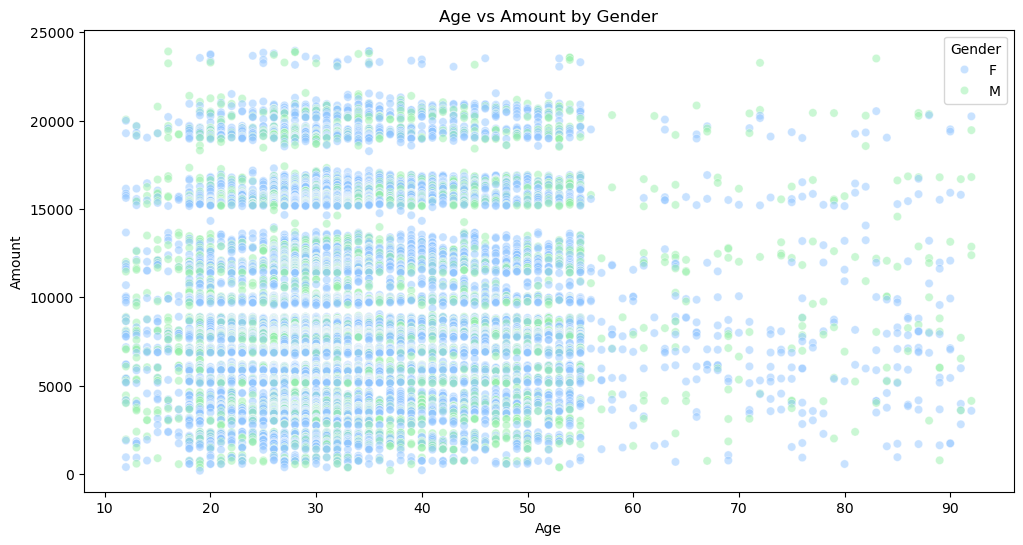

In [35]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='Age', y='Amount', hue='Gender', alpha=0.5)
plt.title("Age vs Amount by Gender")
plt.show()

#### Key Observations

* Correlation = 0.031 (Age alone cannot predict how much someone spends)
* Uniform spend across ages (All age groups have both high and low spenders)
* No gender-age interaction (Gender and age don't combine to create spending trends)
* Dense 15–50 cluster (This is where volume comes from, not higher per-order spend)

**Key Insight:**
* Spending amount in this dataset is driven by what people buy (product category)
  and who they are (occupation, marital status) — not how old they are
* Age groups differ in total revenue only because of differences in customer count,
  not because older or younger customers spend more per transaction.